# 🦺 PPE Detection — YOLOv8 Training
### بنعمل fine-tune لـ YOLOv8 على dataset خاص بـ PPE
---
**خطوات:**
1. Install المكتبات
2. Download الـ Dataset من Roboflow
3. Train الموديل
4. Evaluate النتائج
5. Test على صورة/فيديو

## ✅ Step 1 — Install Libraries

In [1]:
!pip install ultralytics roboflow -q
import ultralytics
ultralytics.checks()

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.5/112.6 GB disk)


## 📦 Step 2 — Download Dataset من Roboflow

In [2]:
from roboflow import Roboflow

rf = Roboflow(api_key="2ZAM2B4Ms6bJxyf8h3qW")
project = rf.workspace("vijetha-pugst").project("ppe-detection-zfbqw")
version = project.version(1)
dataset = version.download("yolov8")

print("✅ Dataset downloaded!")
print(f"📁 Path: {dataset.location}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to PPE-Detection-1 in yolov8:: 100%|██████████| 3415/3415 [00:00<00:00, 6865.12it/s]

✅ Dataset downloaded!
📁 Path: /content/PPE-Detection-1


## 🔍 Step 3 — Check Dataset

In [3]:
import os

data_yaml = os.path.join(dataset.location, "data.yaml")

# اعرض محتوى الـ yaml
with open(data_yaml, 'r') as f:
    print(f.read())

# عد الصور
train_path = os.path.join(dataset.location, "train", "images")
val_path   = os.path.join(dataset.location, "valid", "images")

print(f"\n🖼 Train images : {len(os.listdir(train_path))}")
print(f"🖼 Valid images : {len(os.listdir(val_path))}")

names:
- Cap
- Gloves
- Googles
- No-Cap
- Person
- White_C
nc: 6
roboflow:
  license: CC BY 4.0
  project: ppe-detection-zfbqw
  url: https://universe.roboflow.com/vijetha-pugst/ppe-detection-zfbqw/dataset/1
  version: 1
  workspace: vijetha-pugst
test: ../test/images
train: ../train/images
val: ../valid/images


🖼 Train images : 1404
🖼 Valid images : 201


## 🚀 Step 4 — Train YOLOv8

In [4]:
from ultralytics import YOLO

# Load pretrained YOLOv8n (nano — أسرع على Colab)
model = YOLO("yolov8n.pt")

# Train
results = model.train(
    data=data_yaml,
    epochs=50,        # عدد الـ epochs
    imgsz=640,        # حجم الصورة
    batch=16,         # batch size
    name="ppe_model", # اسم الـ run
    project="PPE",    # اسم الفولدر
    patience=10,      # early stopping
    device=0,         # GPU
    verbose=True
)

print("✅ Training Done!")

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/PPE-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ppe_model, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patienc

## 📊 Step 5 — Evaluate النتائج

In [8]:
import glob
from ultralytics import YOLO

# الـ path ظاهر في الـ output
best_model = YOLO("/content/runs/detect/PPE/ppe_model/weights/best.pt")

metrics = best_model.val(data=data_yaml)

print(f"\n📈 mAP50     : {metrics.box.map50:.3f}")
print(f"📈 mAP50-95  : {metrics.box.map:.3f}")
print(f"📈 Precision : {metrics.box.mp:.3f}")
print(f"📈 Recall    : {metrics.box.mr:.3f}")

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 901.9±314.5 MB/s, size: 39.7 KB)
val: Scanning /content/PPE-Detection-1/valid/labels.cache... 201 images, 20 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 201/201 42.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 2.8it/s 4.7s
                   all        201        429      0.636      0.724      0.697      0.427
                   Cap         61        118      0.658      0.822       0.71      0.367
                Gloves         34         58      0.668      0.655      0.652      0.408
               Googles         90        107      0.745      0.841      0.857      0.568
                No-Cap          4          4      0.423      0.385      0.373      0.197
                Person         68        

## 🖼 Step 6 — Test على صورة

✅ صورة للتجربة: /content/PPE-Detection-1/valid/images/202286-3-_jpg.rf.0686acc980e800899c0347528a6bb1e8.jpg

image 1/1 /content/PPE-Detection-1/valid/images/202286-3-_jpg.rf.0686acc980e800899c0347528a6bb1e8.jpg: 640x640 2 Caps, 2 Persons, 8.4ms
Speed: 2.0ms preprocess, 8.4ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/PPE_test/results


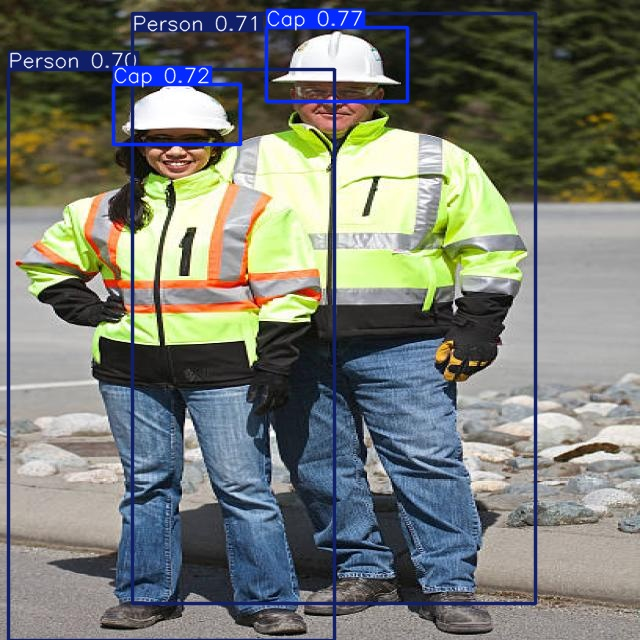

In [11]:
from ultralytics import YOLO
from IPython.display import Image, display
import glob, os

# الـ path الصح
best_model = YOLO("/content/runs/detect/PPE/ppe_model/weights/best.pt")

# صور الـ validation
val_images = glob.glob("/content/runs/detect/PPE/ppe_model/val/images/*.jpg")

# لو مش لاقي صور هناك جيبها من الـ dataset
if not val_images:
    val_images = glob.glob("/content/**/valid/images/*.jpg", recursive=True)

print(f"✅ صورة للتجربة: {val_images[0]}")

results = best_model.predict(
    source=val_images[0],
    conf=0.5,
    save=True,
    project="/content/PPE_test",
    name="results"
)

# عرض النتيجة
result_img = glob.glob("/content/PPE_test/results/*.jpg")[0]
display(Image(filename=result_img, width=800))

## 💾 Step 7 — Download الموديل

In [13]:
from google.colab import files

files.download("/content/runs/detect/PPE/ppe_model/weights/best.pt")
print("✅ Model downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Model downloaded!
